In [1]:
from pathlib import Path

import anndata as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# ----- Edit these paths for your environment -----
DATA_PATH = "data/75k_unstable_anndata_log2tmmcpm_classification.h5ad"
RESULT_DIR = "results"
PLOT_DIR = "plots"

# Filename prefixes produced by train_multiclass_linear_svm.py / train_binary_linear_svm.py
MULTICLASS_LINEAR_PREFIX = "multiclass_linear_svm"
BINARY_LINEAR_PREFIX     = "binary_linear_svm"
import os
os.makedirs(PLOT_DIR, exist_ok=True)

In [ ]:
confusion = pd.read_csv(f"{RESULT_DIR}/{MULTICLASS_LINEAR_PREFIX}_confusion_matrix.csv", index_col=0)

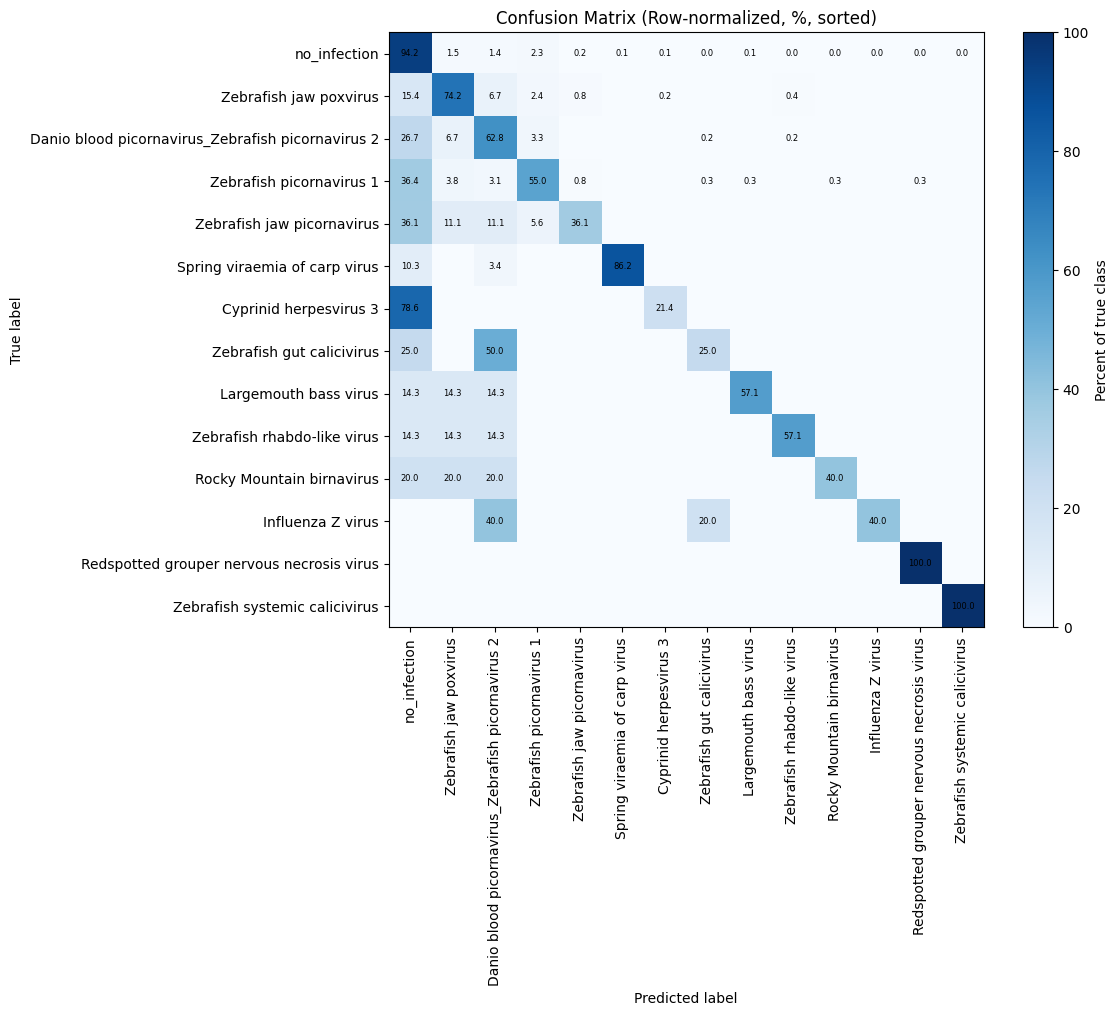

In [3]:
# Row-normalized confusion matrix (percent of true class)
import matplotlib.pyplot as plt


row_sums = confusion.sum(axis=1).replace(0, np.nan)
confusion_pct = (confusion.div(row_sums, axis=0) * 100).fillna(0)

# Sort rows/columns by label counts (if available)

if "labels" in globals():
    order = labels.value_counts().index.tolist()
else:
    order = row_sums.sort_values(ascending=False).index.tolist()

confusion_pct = confusion_pct.reindex(index=order, columns=order)

plt.figure(figsize=(12, 10))
plt.imshow(confusion_pct.values, interpolation="nearest", cmap="Blues", vmin=0, vmax=100)
plt.colorbar(label="Percent of true class")

plt.xticks(range(len(confusion_pct.columns)), confusion_pct.columns, rotation=90)
plt.yticks(range(len(confusion_pct.index)), confusion_pct.index)

# Annotate nonzero values
for i in range(confusion_pct.shape[0]):
    for j in range(confusion_pct.shape[1]):
        val = confusion_pct.iat[i, j]
        if val > 0:
            plt.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=6, color="black")

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix (Row-normalized, %, sorted)")
plt.tight_layout()
plt.show()

In [ ]:
scores = pd.read_csv(
    f"{RESULT_DIR}/{MULTICLASS_LINEAR_PREFIX}_scores.csv",
    index_col=0,
)

In [5]:
# Determine top 5 true classes by count (exclude no_infection)
label_counts = scores["y_true"].value_counts()
top5 = label_counts.drop("no_infection").head(5).index.tolist()

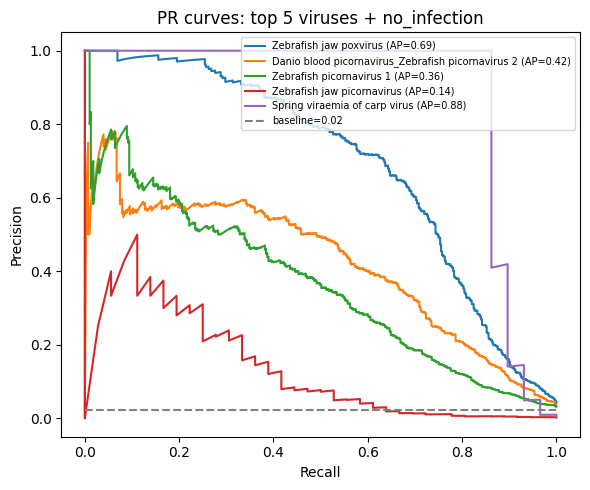

In [6]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Plot PR (AUPRC) curves together for top 5 viruses + no_infection
classes_to_plot = list(top5)

plt.figure(figsize=(6, 5))
for cls in classes_to_plot:
    if cls not in scores.columns:
        continue
    y_true = (scores["y_true"] == cls).astype(int)
    y_score = scores[cls]
    precision, recall, _ = precision_recall_curve(y_true, y_score)
    ap = average_precision_score(y_true, y_score)
    plt.plot(recall, precision, label=f"{cls} (AP={ap:.2f})")

# Baseline: prevalence line (average across selected classes)
prevalences = []
for cls in classes_to_plot:
    if cls not in scores.columns:
        continue
    prevalences.append((scores["y_true"] == cls).mean())
if prevalences:
    baseline = sum(prevalences) / len(prevalences)
    plt.hlines(baseline, 0, 1, colors="gray", linestyles="--", label=f"baseline={baseline:.2f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR curves: top 5 viruses + no_infection")
plt.legend(fontsize=7)
plt.tight_layout()
plt.show()

In [ ]:
classes_to_plot

['Zebrafish jaw poxvirus',
 'Danio blood picornavirus_Zebrafish picornavirus 2',
 'Zebrafish picornavirus 1',
 'Zebrafish jaw picornavirus',
 'Spring viraemia of carp virus']

In [ ]:
importance = pd.read_csv(f"{RESULT_DIR}/{MULTICLASS_LINEAR_PREFIX}_gene_importance.csv", index_col=0)

In [ ]:
# Classes used for downstream plots
selected_classes = ["no_infection"] + list(top5)

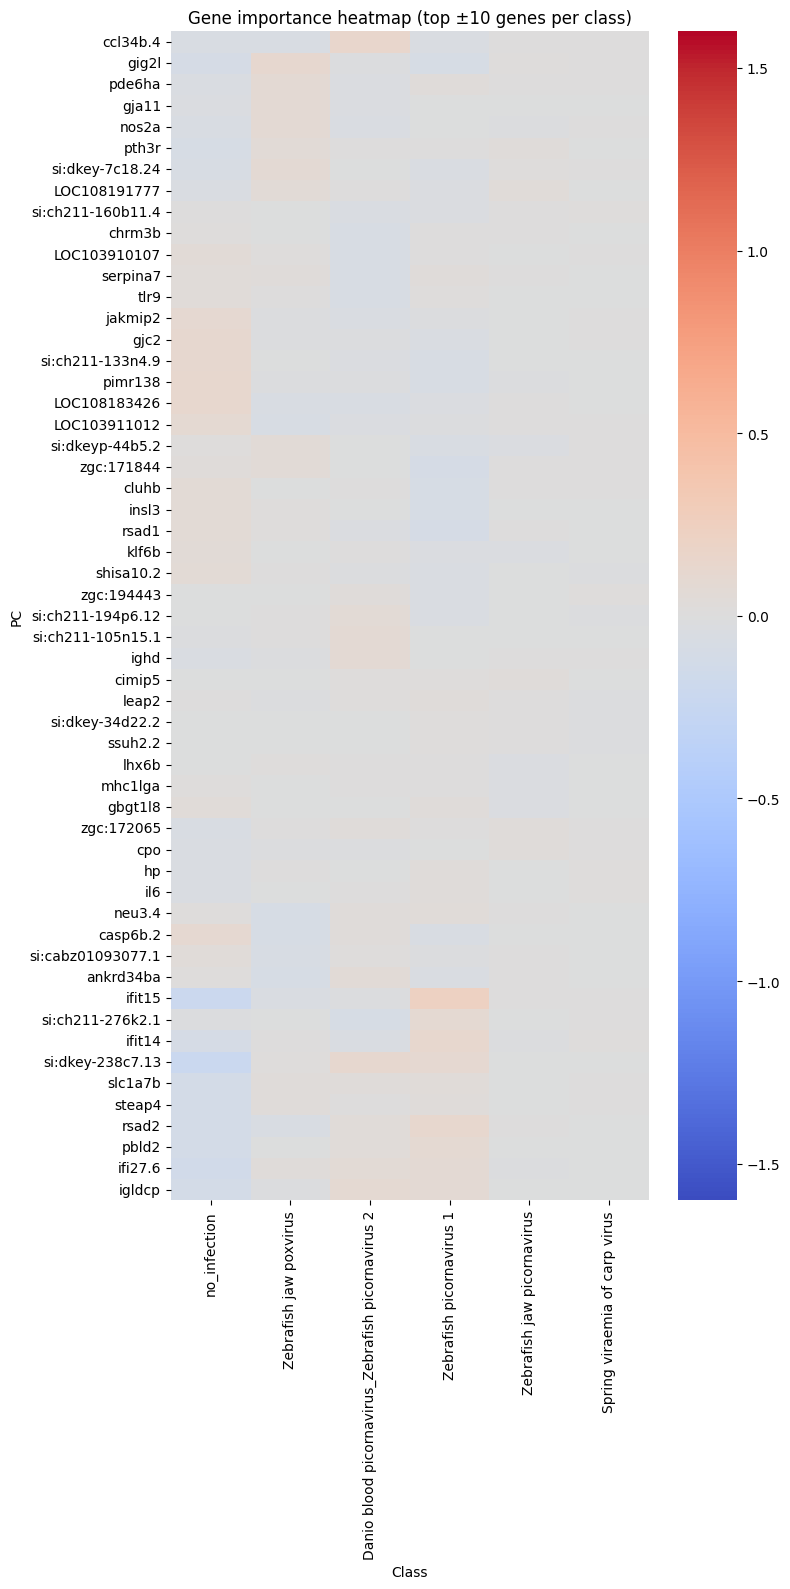

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Heatmap of PCA importance for selected classes
# Use top 10 positive and top 10 negative PCs per class

subset = importance.loc[selected_classes].T  # PCs x classes

selected_pcs = set()
for cls in selected_classes:
    row = subset[cls]
    top_pos = (row.sort_values(ascending=False).head(5).index)
    top_neg = (row.sort_values(ascending=True).head(5).index)
    selected_pcs.update(top_pos)
    selected_pcs.update(top_neg)

# Exclude genes starting with si, LOC, or zgc
# selected_pcs = {
#     gene
#     for gene in selected_pcs
#     if not str(gene).lower().startswith(("si:", "loc", "zgc"))
# }

# Keep the same order as duo_list
try:
    common_idx = [g for g in duo_list if g in subset.index]
except NameError:
    common_idx = [g for g in selected_pcs if g in subset.index]
filtered = subset.loc[common_idx, selected_classes]

# Reorder rows by hierarchical clustering to group similar patterns
from scipy.cluster.hierarchy import linkage, leaves_list
row_linkage = linkage(filtered.values, method="average", metric="euclidean")
row_order = leaves_list(row_linkage)
filtered = filtered.iloc[row_order]

plt.figure(figsize=(8, 16))
sns.heatmap(filtered, cmap="coolwarm", center=0, vmin=-1.6, vmax=1.6)
plt.title("Gene importance heatmap (top ±10 genes per class)")
plt.xlabel("Class")
plt.ylabel("PC")
plt.tight_layout()
plt.show()

In [ ]:
row

slc35a5            -0.000393
ccdc80             -0.001878
nrf1                0.001271
ube2h              -0.000240
nherf1a             0.003114
                      ...   
LOC110438138        0.004827
LOC137487333       -0.000884
LOC110438083        0.001475
si:dkey-45d16.4    -0.002223
si:dkey-205h23.1   -0.001307
Name: Spring viraemia of carp virus, Length: 22252, dtype: float64

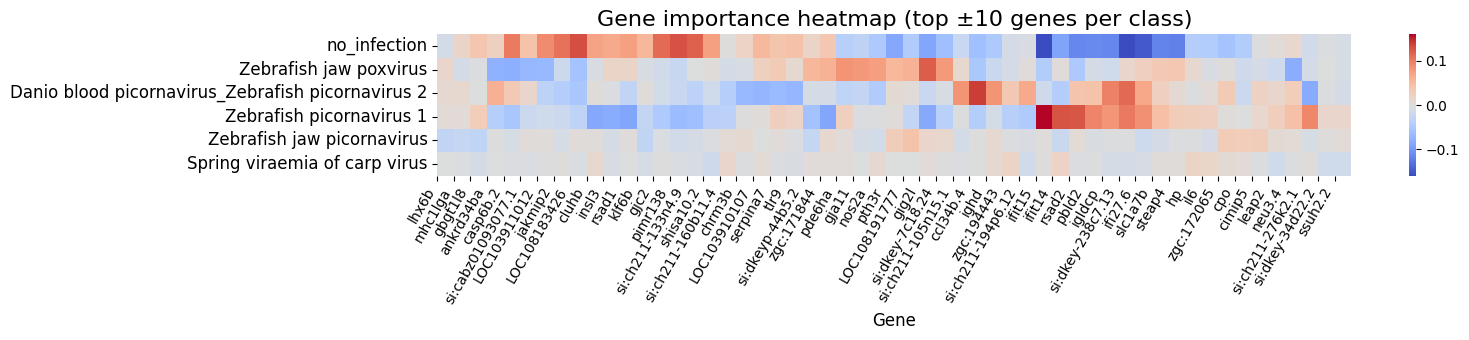

In [12]:
# Transposed heatmap: genes as columns (clustered by rows of filtered)
from scipy.cluster.hierarchy import linkage, leaves_list

# Cluster rows (genes) of filtered based on their profiles across classes
row_data = filtered.to_numpy()
row_link = linkage(row_data, method="average", metric="correlation")
row_order = leaves_list(row_link)

clustered = filtered.iloc[row_order, :].T

plt.figure(figsize=(16, 3.5))
ax = sns.heatmap(clustered, cmap="coolwarm", center=0, vmin=-0.16, vmax=0.16)
plt.title("Gene importance heatmap (top ±10 genes per class)", fontsize=16)
plt.xlabel("Gene", fontsize=12)
plt.ylabel("")
ax.set_xticks(range(len(clustered.columns)))
ax.set_xticklabels(clustered.columns, rotation=60, ha="right")
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()


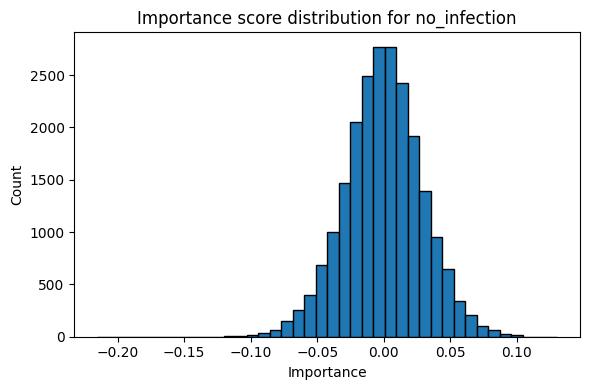

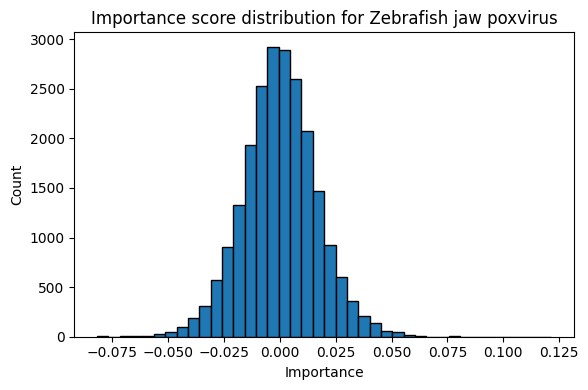

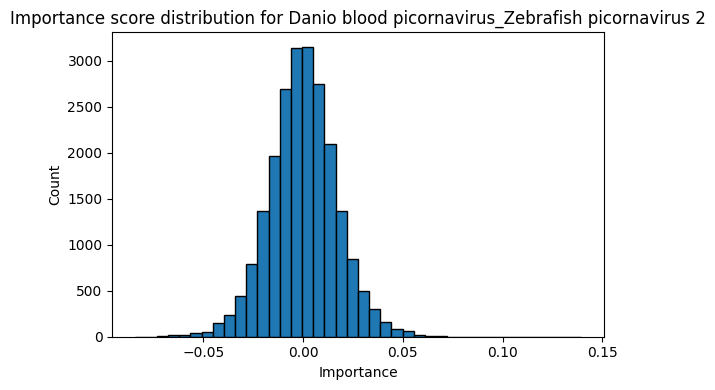

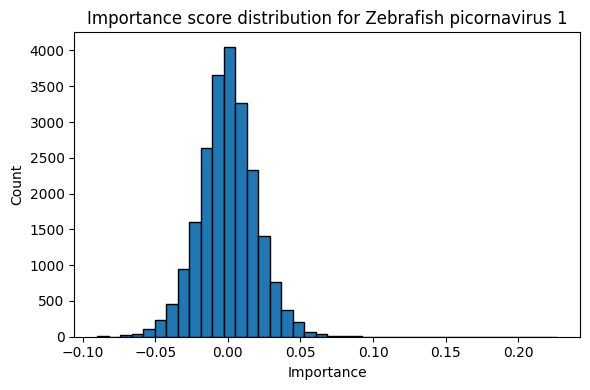

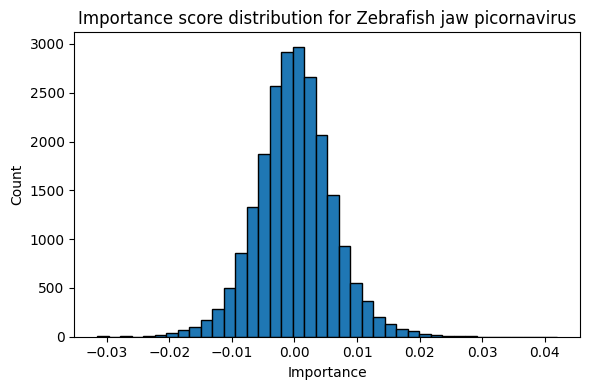

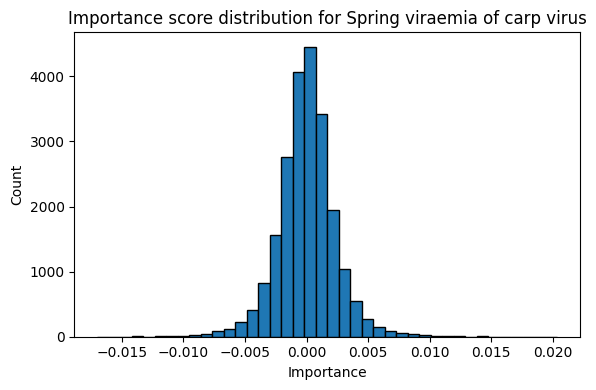

In [13]:
# Histogram of importance scores (40 bins) for each class
subset = importance.loc[selected_classes].T  # PCs x classes

for cls in selected_classes:
    plt.figure(figsize=(6, 4))
    values = subset[cls].dropna().to_numpy()
    plt.hist(values, bins=40, edgecolor="black")
    plt.title(f"Importance score distribution for {cls}")
    plt.xlabel("Importance")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


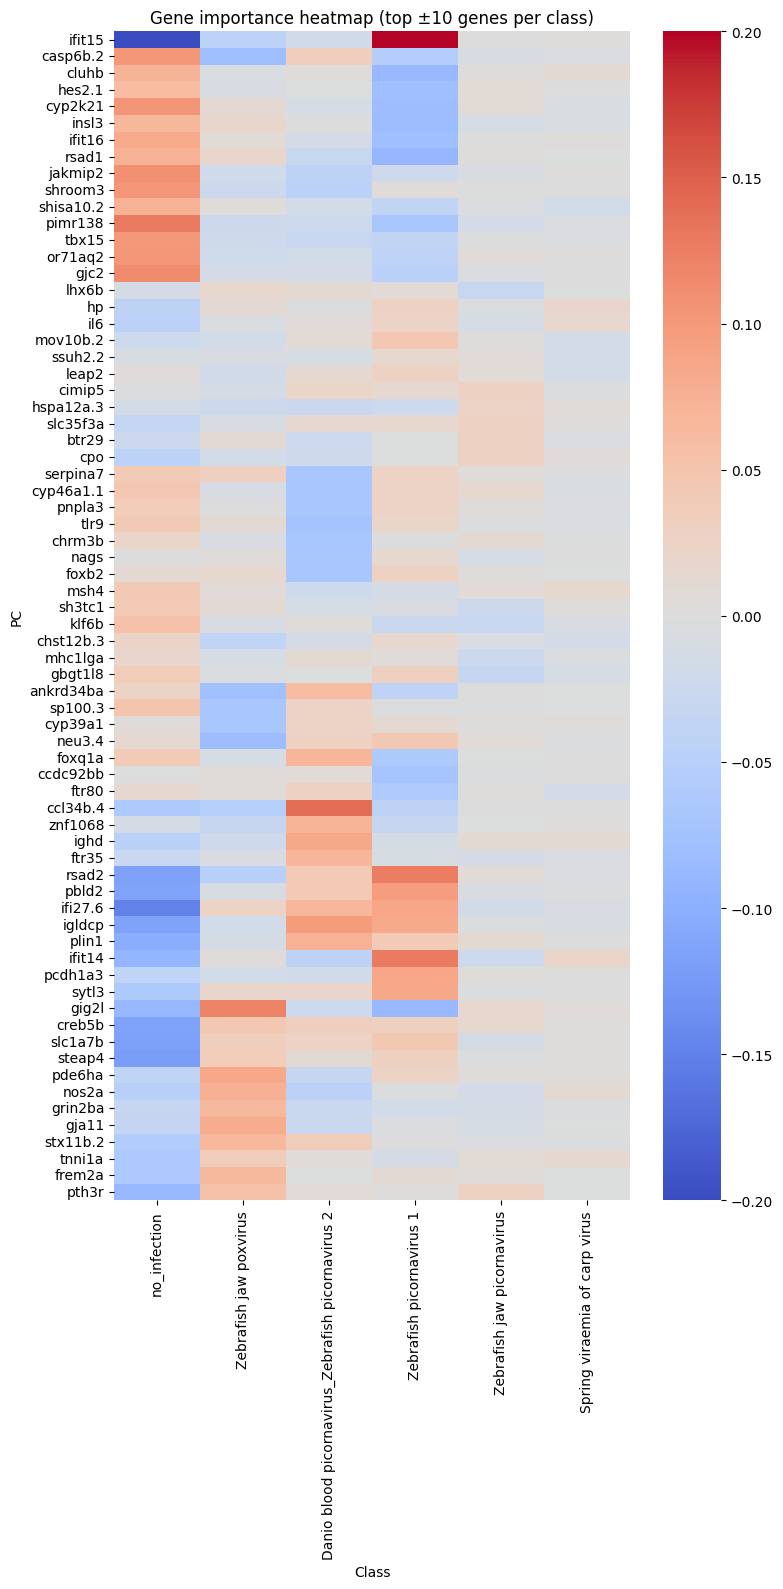

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Heatmap of PCA importance for selected classes
# Use top 10 positive and top 10 negative PCs per class

subset = importance.loc[selected_classes].T  # PCs x classes

selected_pcs = set()
for cls in selected_classes:
    row = subset[cls]
    top_pos = (row.sort_values(ascending=False).head(10).index)
    top_neg = (row.sort_values(ascending=True).head(10).index)
    selected_pcs.update(top_pos)
    selected_pcs.update(top_neg)

# Exclude genes starting with si, LOC, or zgc
selected_pcs = {
    gene
    for gene in selected_pcs
    if not str(gene).lower().startswith(("si:", "loc", "zgc"))
}

# Keep the same order as duo_list
try:
    common_idx = [g for g in duo_list if g in subset.index]
except NameError:
    common_idx = [g for g in selected_pcs if g in subset.index]
filtered = subset.loc[common_idx, selected_classes]

# Reorder rows by hierarchical clustering to group similar patterns
from scipy.cluster.hierarchy import linkage, leaves_list
row_linkage = linkage(filtered.values, method="average", metric="euclidean")
row_order = leaves_list(row_linkage)
filtered = filtered.iloc[row_order]

plt.figure(figsize=(8, 16))
sns.heatmap(filtered, cmap="coolwarm", center=0, vmin=-0.2, vmax=0.2)
plt.title("Gene importance heatmap (top ±10 genes per class)")
plt.xlabel("Class")
plt.ylabel("PC")
plt.tight_layout()
plt.show()

In [ ]:
# Combine multiclass (six classes) with infected from binary plot

# Multiclass importance matrix (classes x genes)
multiclass_df = importance.loc[selected_classes].copy()

# Infected weights from full binary importance (no_infection stays multiclass)
try:
    binary_weights = binary_weights  # type: ignore[name-defined]
except NameError:
    importance_path = f"{RESULT_DIR}/{BINARY_LINEAR_PREFIX}_gene_importance.csv"
    importance_df = pd.read_csv(importance_path, index_col=0)
    binary_weights = importance_df.iloc[0]

# Collect top 5 positive and negative genes per class (multiclass)
multiclass_genes = set()
for cls in multiclass_df.index:
    row = multiclass_df.loc[cls].dropna()
    multiclass_genes.update(row.sort_values(ascending=False).head(5).index)
    multiclass_genes.update(row.sort_values(ascending=True).head(5).index)

# Top genes from infected (binary) class
infected_top = binary_weights.dropna()
infected_genes = set()
infected_genes.update(infected_top.sort_values(ascending=False).head(10).index)
infected_genes.update(infected_top.sort_values(ascending=True).head(10).index)

# Order x-axis: infected genes first, then multiclass-only genes
infected_list = [g for g in infected_top.index if g in infected_genes]
multiclass_only_list = [g for g in multiclass_genes if g not in infected_genes]

# Build combined dataframe for selected genes only
selected_genes = infected_list + sorted(multiclass_only_list)
multiclass_sel = multiclass_df.reindex(columns=selected_genes)
infected_row = pd.DataFrame([(-binary_weights.reindex(selected_genes))], index=["infected"])

# Order rows: multiclass no_infection, infected, then remaining classes
ordered_rows = []
if "no_infection" in multiclass_sel.index:
    ordered_rows.append("no_infection")
ordered_rows.append("infected")
ordered_rows += [
    cls
    for cls in multiclass_sel.index
    if cls not in {"no_infection", "infected"}
]

combined_df = pd.concat([multiclass_sel, infected_row], axis=0)
combined_df = combined_df.loc[ordered_rows]

# Keep a copy for downstream plotting cells
plot_df = combined_df.copy()

# Cluster genes within each chunk by pattern
from scipy.cluster.hierarchy import linkage, leaves_list

ordered_infected = infected_list
if len(infected_list) > 1:
    inf_data = combined_df[infected_list].T.to_numpy()
    inf_link = linkage(inf_data, method="average", metric="correlation")
    ordered_infected = [infected_list[i] for i in leaves_list(inf_link)]

ordered_multi = sorted(multiclass_only_list)
if len(multiclass_only_list) > 1:
    multi_data = combined_df[multiclass_only_list].T.to_numpy()
    multi_link = linkage(multi_data, method="average", metric="correlation")
    ordered_multi = [multiclass_only_list[i] for i in leaves_list(multi_link)]

selected_genes = ordered_infected + ordered_multi
combined_df = combined_df.reindex(columns=selected_genes)

max_abs = float(np.nanmax(np.abs(combined_df.values))) if not combined_df.empty else 0.1

plt.figure(figsize=(16, 4.5))
ax = sns.heatmap(combined_df, cmap="coolwarm", center=0, vmin=-0.16, vmax=0.16)
plt.title("Gene importance heatmap", fontsize=16, y=1.25)
plt.xlabel("Gene", fontsize=12)
plt.ylabel("", fontsize=12)
ax.set_xticks(np.arange(len(combined_df.columns))+0.5)
ax.set_xticklabels(combined_df.columns, rotation=60, ha="right")

# Shift x labels slightly to the right; smaller font, bold for highlighted genes
BOLD_GENES = {"rsad2", "ifit15", "bcl10", "ccl34b.4", "ighd", "nos2a", "gja1", "il6", "hp", "ifit14"}
for label in ax.get_xticklabels():
    label.set_x(label.get_position()[0] + 0.5)
    label.set_fontsize(8.5)
    if label.get_text() in BOLD_GENES:
        label.set_fontweight("bold")

# Visual separator between infected and multiclass-only genes
sep_idx = len(ordered_infected)
ax.axvline(sep_idx, color="black", linewidth=1)

# Chunk annotations
ax.text(
    sep_idx / 2,
    -0.6,
    "Top ±10 genes (binary)",
    ha="center",
    va="bottom",
    fontsize=10,
)
ax.text(
    sep_idx + (len(combined_df.columns) - sep_idx) / 2,
    -0.6,
    "Top ±5 genes (multiclass)",
    ha="center",
    va="bottom",
    fontsize=10,
)

plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/svm_gene_importance_heatmap.pdf", dpi=300)
plt.show()

In [16]:
importance_df

,slc35a5,ccdc80,nrf1,ube2h,nherf1a,dap,itsn1,myh10,tmem267,thraa,...,LOC100333722,LOC137496448,LOC110439932,LOC101886145,LOC137488218,LOC110438138,LOC137487333,LOC110438083,si:dkey-45d16.4,si:dkey-205h23.1
infected_vs_no_infection,0.007514,0.046037,-0.024595,0.0384,-0.000654,-0.023698,0.015534,-0.034911,0.01933,0.020896,...,-0.038329,-0.063388,-0.029782,0.022309,0.046327,0.026206,0.003367,0.082763,-0.00153,-0.025642
